# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [6]:

dir = "./../../data/uvtable/"
data_file = dir + "uvtable_SimulatedBlob.txt"
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

# Load data
file = np.loadtxt(data_file, unpack=True)
u, v, Re, Im, Weights = file
Vis = Re + 1j*Im
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

In [7]:
Rmax = 3*rout
Qmax = max(np.hypot(u,v))

import math

N = math.floor(5* Rmax/rad_to_arcsec * Qmax)

In [8]:
Qmax

8828201.715647701

In [9]:
N

642

In [10]:
Qmin = min(np.hypot(u,v))
Qmin

11479.355483435862

In [11]:
N

642

In [49]:
routs = [rout, 2*rout, 3*rout, 4*rout, 5*rout, 6*rout]

In [13]:
Ns = []
for i in range(len(routs)):
    N = math.floor(5* routs[i]/rad_to_arcsec * Qmax)
    Ns.append(N)
    cellsize = (2*routs[i])/N
    print("For rout = ", routs[i], ", cellsize = ", cellsize, " arcsec, ", "N = ", N)

For rout =  1 , cellsize =  0.009345794392523364  arcsec,  N =  214
For rout =  2 , cellsize =  0.009345794392523364  arcsec,  N =  428
For rout =  3 , cellsize =  0.009345794392523364  arcsec,  N =  642
For rout =  4 , cellsize =  0.009345794392523364  arcsec,  N =  856
For rout =  5 , cellsize =  0.009345794392523364  arcsec,  N =  1070
For rout =  6 , cellsize =  0.009345794392523364  arcsec,  N =  1284


In [14]:
frank2d_objects = []

In [15]:
q_min = np.hypot(u,v).min()
q_max = np.hypot(u,v).max()
print(f"-> q_min data: {q_min}, q_max data: {q_max}")

for i in range(len(routs)):
    print("\nCreating Frank2D object with N = ", Ns[i], " and rout = ", routs[i])
    frank2d = Frank2D(Ns[i], routs[i])
    frank2d_objects.append(frank2d)

    q_min_f2d = np.unique(np.sort(np.hypot(frank2d.u, frank2d.v)))[1]
    q_max_f2d = np.unique(np.sort(np.hypot(frank2d.u, frank2d.v)))[-1]
    print(f"-> q_min frank2d: {q_min_f2d}, q_max frank2d: {q_max_f2d}")

-> q_min data: 11479.355483435862, q_max data: 8828201.715647701

Creating Frank2D object with N =  214  and rout =  1
-> q_min frank2d: 145851.2432174512, q_max frank2d: 15606083.024267279

Creating Frank2D object with N =  428  and rout =  2
-> q_min frank2d: 72925.6216087256, q_max frank2d: 15606083.024267279

Creating Frank2D object with N =  642  and rout =  3
-> q_min frank2d: 48617.081072483736, q_max frank2d: 15606083.02426728

Creating Frank2D object with N =  856  and rout =  4
-> q_min frank2d: 36462.8108043628, q_max frank2d: 15606083.024267279

Creating Frank2D object with N =  1070  and rout =  5
-> q_min frank2d: 29170.248643490235, q_max frank2d: 15606083.024267275

Creating Frank2D object with N =  1284  and rout =  6
-> q_min frank2d: 24308.540536241868, q_max frank2d: 15606083.02426728


### Load objects

In [27]:
# load objects
frank2d_objects = []
import pickle
dir_ = "./../../data/exp/Rmax_Ns/"
for i in range(len(routs)):
    with open(dir_ + "SimulatedBlob_N"+str(Ns[i])+"_Rmax"+str(routs[i])+ ".pkl", "rb") as file:
        frank2d = pickle.load(file)
        frank2d_objects.append(frank2d)

### Run frank2d for differents N

In [22]:
best_N50_Rmax1 = {'m': -6.3666741693035425, 'c': 5.938938246794921e+34, 'l': 10000.0}
best_N50_Rmax2 = {'m': -3.3890156358896206, 'c': 3.5614791421537604e+16, 'l': 10000.0}
best_N50_Rmax3 = {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
best_N50_Rmax4 =  {'m': -1.5044655505440632, 'c': 238394.1726792642, 'l': 38670.982529532164}
best_N50_Rmax5 =  {'m': -1.972719134084518, 'c': 58157011.81131077, 'l': 26595.265124130965}
best_N50_Rmax6 = {'m': -2.2313765094040368, 'c': 828789189.6537628, 'l': 18714.93162241083}

In [23]:
frank2d_objects = []

In [24]:
times = []

In [25]:
best_N50 = {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
params = [best_N50_Rmax1, best_N50_Rmax2, best_N50_Rmax3, best_N50_Rmax4, best_N50_Rmax5, best_N50_Rmax6]

In [26]:
for i in range(len(routs)):
    print("\nProcessing Frank2D object with N = ", Ns[i], " and rout = ", routs[i])
    start = time.time()
    frank2d = Frank2D(Ns[i], routs[i])
    frank2d.process_vis(uvtable)
    
    #initial_guess = {'p': -1, 'm': -1, 'logl': 4}
    #frank2d.search_MAP(initial_guess= initial_guess, N = 50)
    #params = frank2d.MAP
    #print("F2D with Rmax =", routs[i], " MAP parameters found: ", params)

    frank2d.fit(data = uvtable, kernel_params = params[i], rtol = 1e-10)
    #save object

    #import pickle
    #dir_ = "./../../data/exp/Rmax_Ns/"
    #print("Saving Frank2D object with Rmax =", routs[i])
    #with open(dir_ +"SimulatedBlob_N"+str(Ns[i])+"_Rmax"+str(routs[i])+ ".pkl", "wb") as file:
    #    pickle.dump(frank2d, file)

    end = time.time()
    total_time = end - start
    times.append(total_time)
    print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with rout ={routs[i]} took {end - start} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")
    frank2d_objects.append(frank2d)



Processing Frank2D object with N =  214  and rout =  1


===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -6.3666741693035425, 'c': 5.938938246794921e+34, 'l': 10000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.00  min |  0.13 seconds
        +  Building system = 0.00  min |  0.13 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 0/50000 [00:00<?, ? iterations/s]

            +  BiCGStab = 0.00  min |  0.05 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.12837274449980327,
 'iterations': 0,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...


     + Setting kernel..
--> time building S_12_T = 0.01  min |  0.63 seconds
--> times building full visibility model = 0.01  min |  0.63 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with rout =1 took 1.6593070030212402 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx

Processing Frank2D object with N =  428  and rout =  2
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -3.3890156358896206, 'c': 3.5614791421537604e+16, 'l': 10000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.01  min |  0.39 seconds
        +  Building system = 0.01  min |  0.39 seconds
===>  Solving linear system...


...

            +  BiCGStab = 0.41  min |  24.38 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.05830061814120853,
 'iterations': 261,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.20  min |  12.18 seconds
--> times building full visibility model = 0.20  min |  12.23 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with rout =4 took 43.56985950469971 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx

Processing Frank2D object with N =  1070  and rout =  5
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.972719134084518, 'c': 58157011.81131077, 'l': 26595.265124130965}
===>  Creating sparse linear system...
        +  Kernel = 0.05  min |  3.11 seconds
        +  Building system = 0.05  min |  3.18 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 218/50000 [00:20<1:18:29, 10.57 iterations/s]


            +  BiCGStab = 0.34  min |  20.62 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.049578319364337604,
 'iterations': 218,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.31  min |  18.56 seconds
--> times building full visibility model = 0.31  min |  18.62 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with rout =5 took 47.339590072631836 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx

Processing Frank2D object with N =  1284  and rout =  6
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.2313765094040368, 'c': 828789189.6537628, 'l': 18714.93162241083}
===>  Creating sparse linear system...
        +  Kernel = 0.06  min |  3.65 seconds
        +  Building system = 0.06  min |  3.73 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 102/50000 [00:10<1:25:01,  9.78 iterations/s]


            +  BiCGStab = 0.17  min |  10.43 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.04239861403318103,
 'iterations': 102,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.44  min |  26.40 seconds
--> times building full visibility model = 0.44  min |  26.47 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with rout =6 took 46.599478244781494 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [63]:
routs_2 = [routs[5]]
Ns_2 = [Ns[5]]

In [64]:
for i in range(len(routs_2)):
    print("\nProcessing Frank2D object with N = ", Ns_2[i], " and rout = ", routs_2[i])
    start = time.time()
    frank2d = Frank2D(Ns_2[i], routs_2[i])
    frank2d.process_vis(uvtable)

    frank2d.fit(data = uvtable, kernel_params = {'m':-2, 'c':1e8, 'l':1e4}, rtol = 1e-10)

    end = time.time()
    total_time = end - start
    times.append(total_time)
    print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with rout ={routs_2[i]} took {end - start} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")
    frank2d_objects.append(frank2d)



Processing Frank2D object with N =  1284  and rout =  6
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2, 'c': 100000000.0, 'l': 10000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.04  min |  2.65 seconds
        +  Building system = 0.04  min |  2.68 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 17/50000 [00:01<1:00:09, 13.85 iterations/s]


            +  BiCGStab = 0.02  min |  1.23 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.04239861403318103,
 'iterations': 17,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...


     + Setting kernel..
--> time building S_12_T = 0.48  min |  28.92 seconds
--> times building full visibility model = 0.48  min |  28.97 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with rout =6 took 39.67579936981201 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx


### Complexity plot 

In [53]:
times_opt = [79.13917201360067, 45.80040846268336, 157.7723855495453, 206.66316488186519, 150.10596057176588, 182.93581110636396]

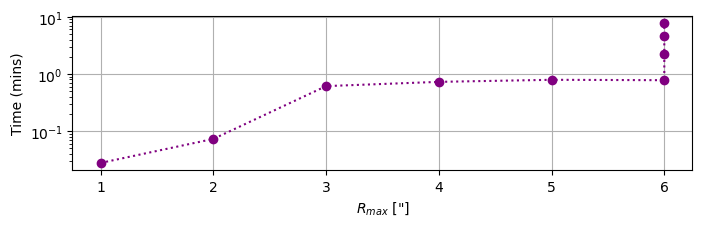

In [54]:
plt.figure(figsize=(8,2))
plt.plot(routs, np.array(times)/60, marker='o', ls=':', color = 'purple')
plt.xlabel( r'$R_{max}$ ["]', fontsize=10)
plt.ylabel('Time (mins)', fontsize=10)
plt.yscale('log')
#plt.ylim(1, 100)
plt.grid()
plt.show()

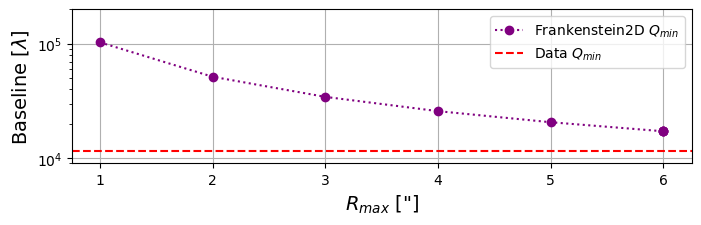

In [55]:
q_min = []
for i in range(len(routs)):
    q_min.append(np.min((np.unique(frank2d_objects[i].FT.q)[1:])))

plt.figure(figsize=(8,2))
plt.plot(routs, np.array(q_min), marker='o', ls=':', color = 'purple', label='Frankenstein2D $Q_{min}$')
plt.axhline(y= Qmin, color='r', linestyle='--', label=r'Data $Q_{min}$')
plt.xlabel( r'$R_{max}$ ["]', fontsize=14)
plt.ylabel(r'Baseline [$\lambda$]', fontsize=14)
plt.yscale('log')
plt.ylim(9e3, 2e5)
plt.legend()
plt.grid()
plt.show()

### Plot differents results

In [56]:
fluxs = []

xxxxxxxxxxxx Total flux:  [0.77633753]


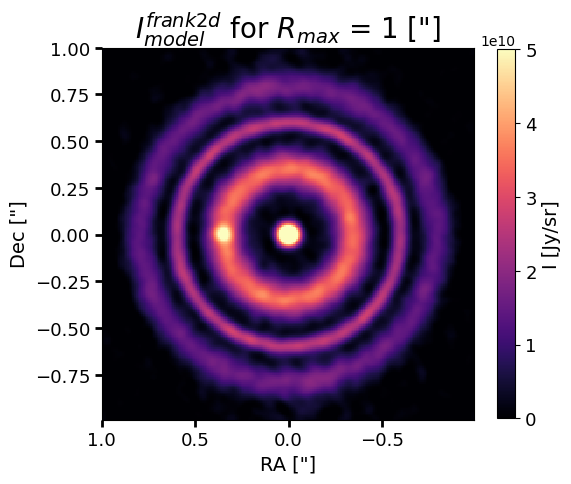

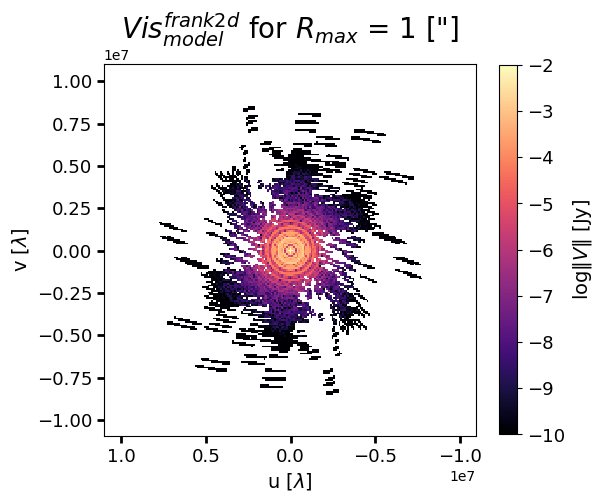

xxxxxxxxxxxx Total flux:  [0.86772992]


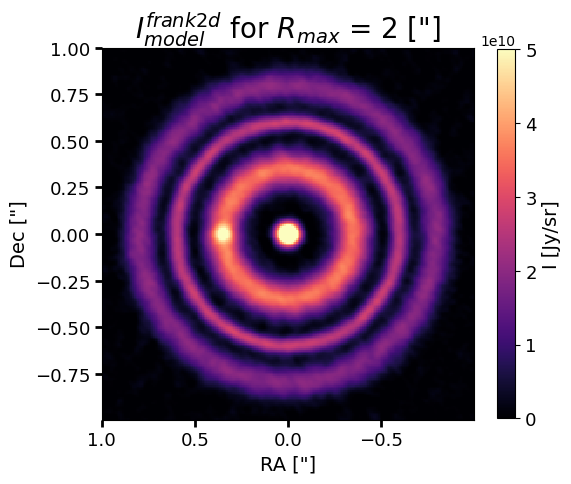

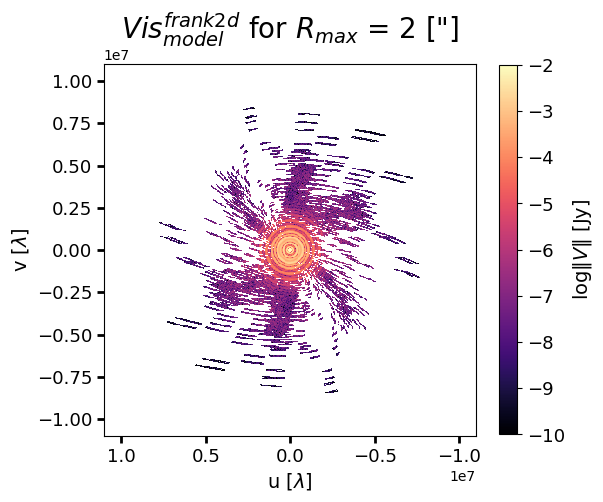

xxxxxxxxxxxx Total flux:  [0.87868756]


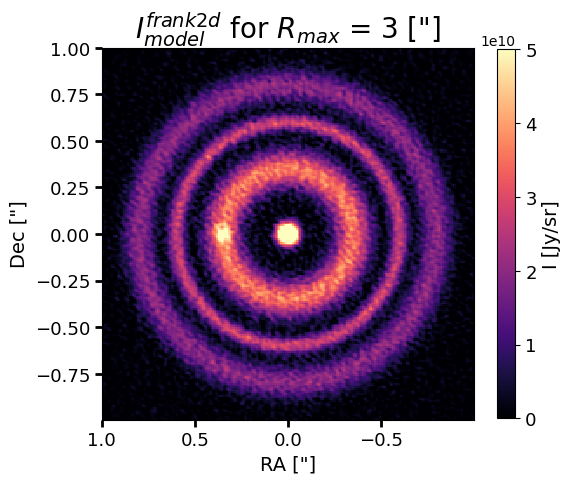

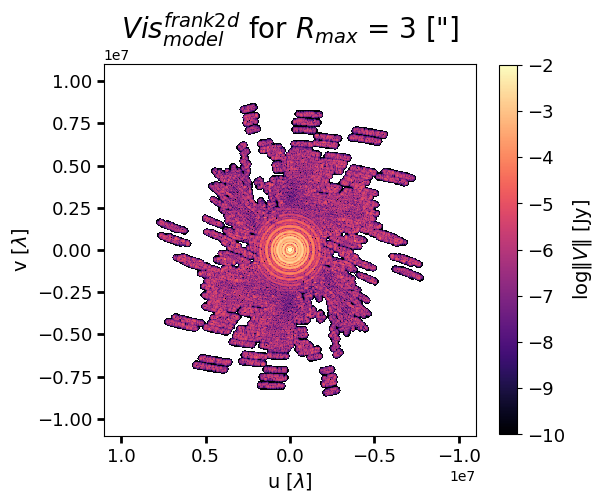

xxxxxxxxxxxx Total flux:  [0.8869046]


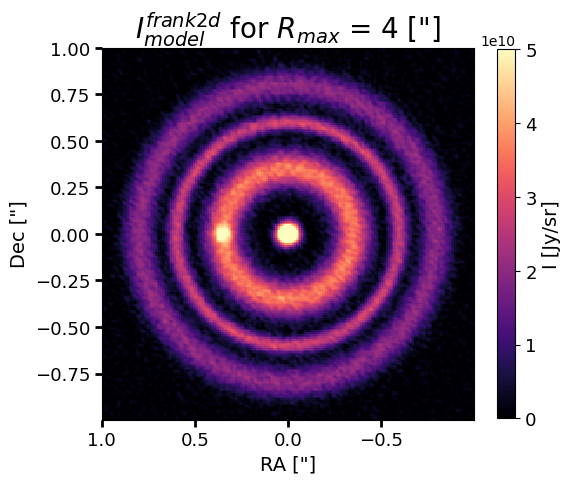

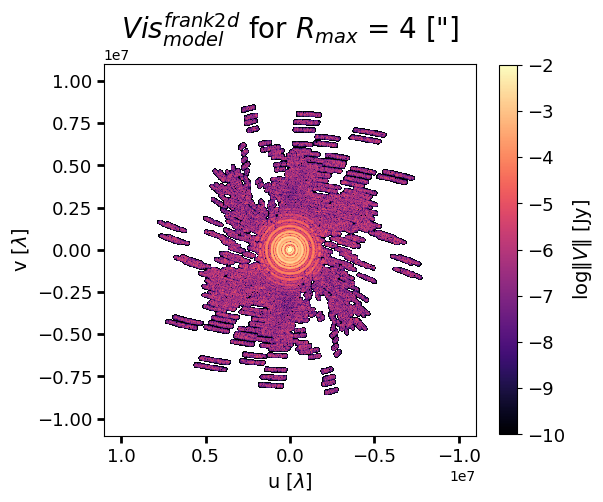

xxxxxxxxxxxx Total flux:  [0.88852901]


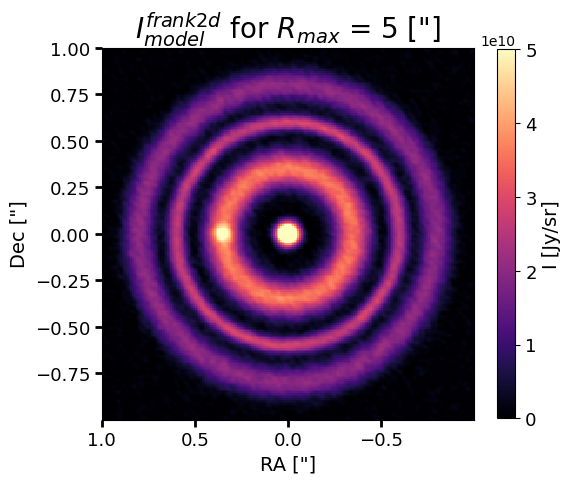

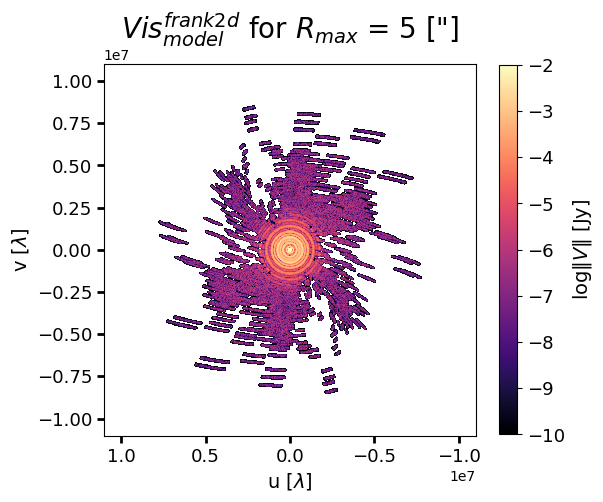

xxxxxxxxxxxx Total flux:  [0.45495064]


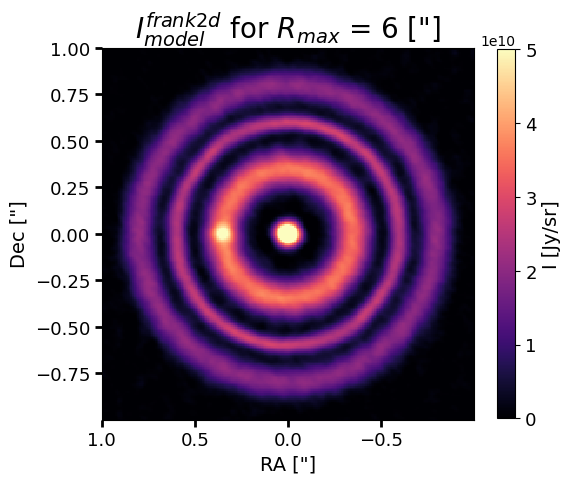

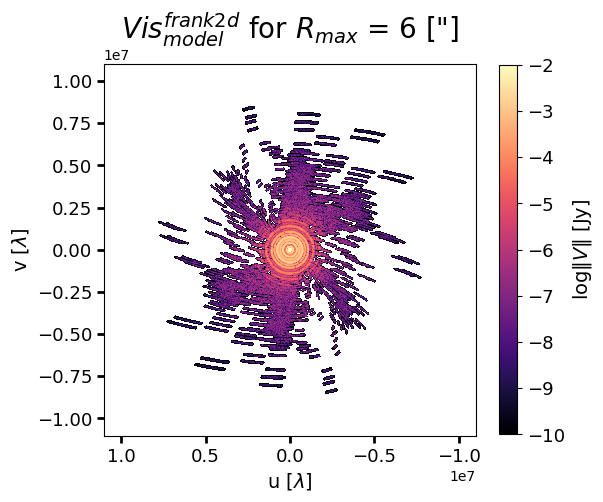

xxxxxxxxxxxx Total flux:  [0.45495064]


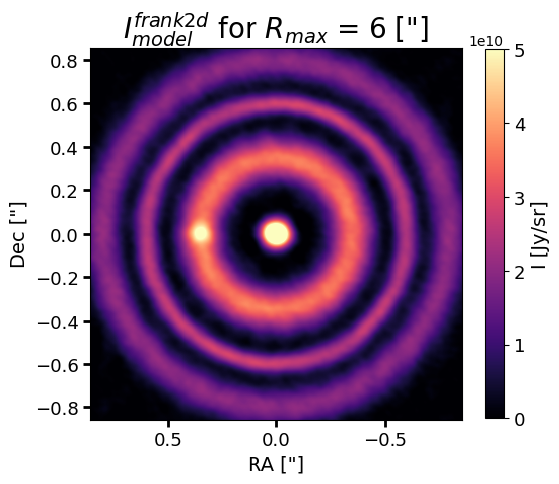

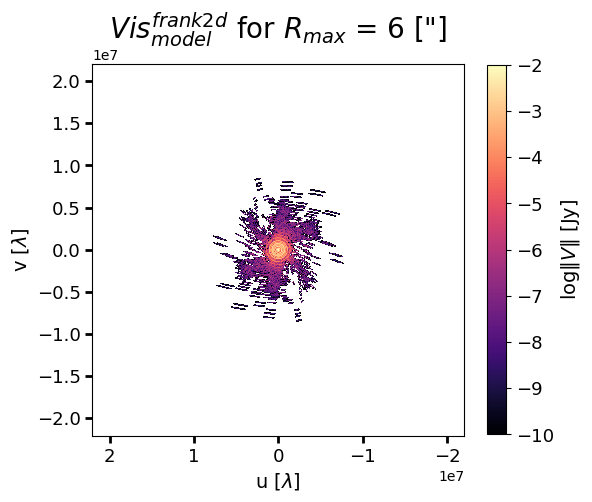

xxxxxxxxxxxx Total flux:  [0.45495064]


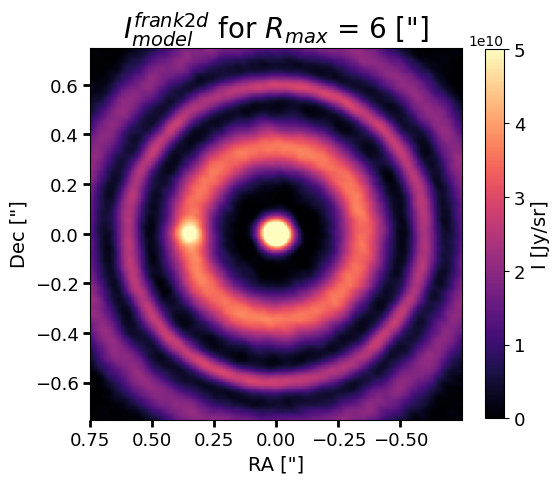

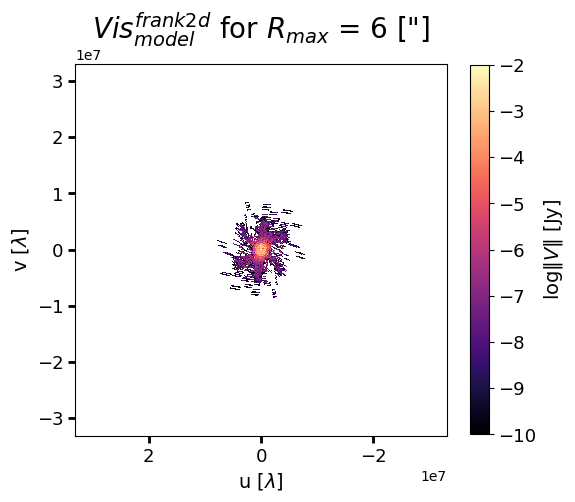

xxxxxxxxxxxx Total flux:  [0.45495064]


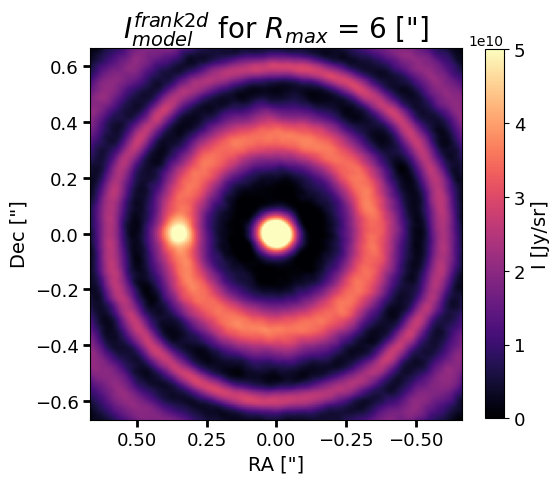

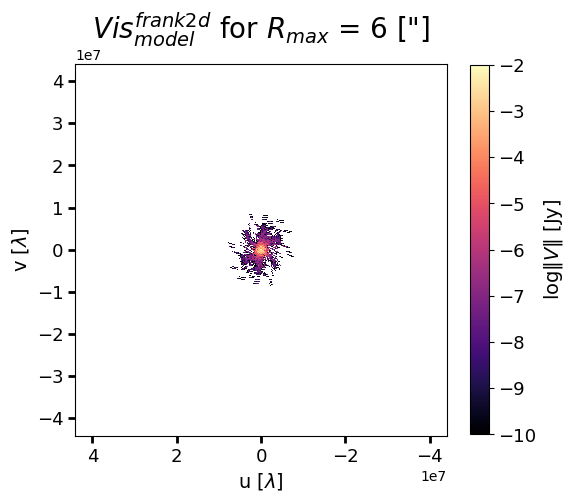

In [65]:
zoom = 1
for i in range(len(routs)):
    Plot_ = Plot(frank2d_objects[i], geom)
    frank2d = frank2d_objects[i]
    u, v = frank2d.u_grid, frank2d.v_grid
    vis = frank2d.visibility_model

    index = np.where((u == 0) & (v == 0))
    V_00 = vis[index].real
    fluxs.append(V_00)
    print("xxxxxxxxxxxx Total flux: ", V_00)
    Plot_.intensity( vmax=5e10,  gamma = 1, zoom=zoom,
                     title= r'$I_{model}^{frank2d}$ for $R_{max}$ = ' + str(routs[i]) + ' ["]')
    Plot_.visibility(fig_size = 6,
                     title = r'$Vis_{model}^{frank2d}$ for $R_{max}$ = ' + str(routs[i])+ ' ["]')
    zoom+=1

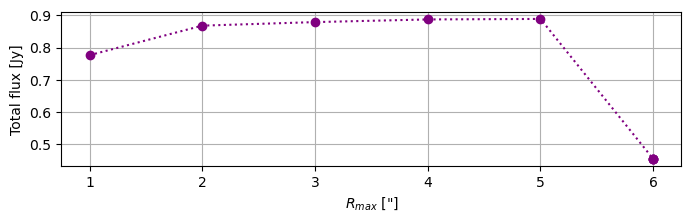

In [58]:
plt.figure(figsize=(8,2))
plt.plot(routs, fluxs, marker='o', ls=':', color = 'purple')
plt.xlabel( r'$R_{max}$ ["]', fontsize=10)
#plt.yscale('log')
plt.ylabel('Total flux [Jy]', fontsize=10)
#plt.ylim(0.7, 0.95)
plt.grid()

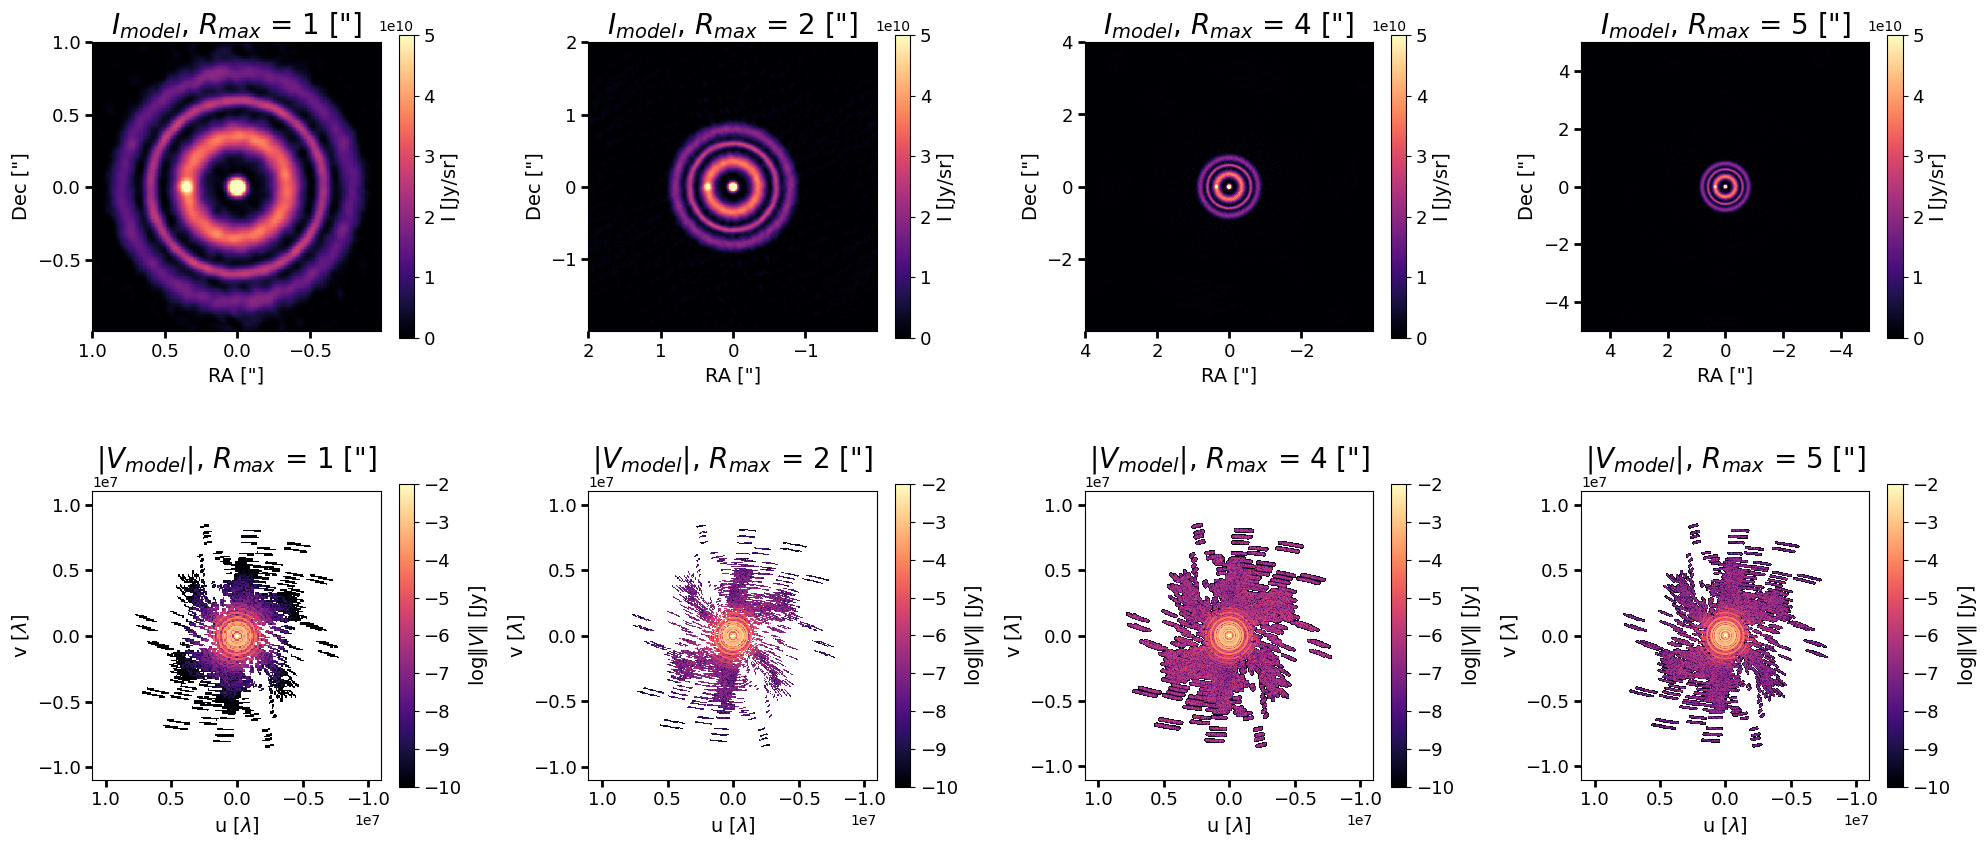

In [59]:
import matplotlib.pyplot as plt

indices_a_plotear = [0, 1, 3, 4]

frank2d_seleccionados = [frank2d_objects[i] for i in indices_a_plotear]
N_seleccionados = [routs[i] for i in indices_a_plotear]

num_cols = len(N_seleccionados)

fig, axes = plt.subplots(nrows=2, ncols=num_cols, figsize=(5 * num_cols, 9))

if num_cols == 1:
    axes = axes.reshape(2, 1)

for i in range(num_cols):
    Plot_ = Plot(frank2d_seleccionados[i], geom) 
    N_valor = N_seleccionados[i] 

    Plot_.intensity(ax=axes[0, i], vmax=5e10, gamma=1, zoom=1,
                     title=r'$I_{model}$, $R_{max}$ = ' + str(N_valor)+ ' ["]')
    
    Plot_.visibility(ax=axes[1, i], fig_size=6,
                      title=r'$|V_{model}|$, $R_{max}$ = ' + str(N_valor) + ' ["]')

plt.tight_layout()
plt.show()